In [2]:
from langchain_core.tools import BaseTool
from dotenv import load_dotenv
from Core.LLMS import build_llm_factory

load_dotenv()
llm_factory = build_llm_factory()

from sqlalchemy import desc
from typing import List, Callable
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.chat_models import BaseChatModel
from Core.Graph.tools import check_product, save_product_data, load_product
from langchain.messages import HumanMessage, AIMessage
from langchain_core.runnables import RunnableConfig
from pydantic import BaseModel , Field 
from langchain.tools import tool , ToolRuntime
import os
from Core.Subgraphs import get_plotting_agent, get_auto_tagging_graph, get_sandbox_graph
from Core.Agents.DataframeAgent.agent import data_analysis_agent
from Core.Agents.SupervisorAgent.agent import supervisor_agent
from Core.Agents.ReporterAgent.agent import reporter_agent
from pathlib import Path
import re
import pandas as pd
import base64

sandbox_graph_data = get_sandbox_graph(llm_factory["coder_llm_data_analysis"][0])
sandbox_graph_plot = get_sandbox_graph(llm_factory["coder_llm_plotting"][0])
plot_agent = get_plotting_agent(
    sandbox_graph=sandbox_graph_plot,
    prompt_llm=llm_factory["planner_llm"][0],
    image_llm=llm_factory["image_llm"][0],
)
tag_agent = get_auto_tagging_graph(
    batch_llm=llm_factory["batch_llms"], cluster_llm=llm_factory["planner_llm"][0]
)

def embed_local_images_as_base64(markdown: str, base_path: str | None = None) -> str:
    base_path = Path(base_path)
    pattern = re.compile(r"!\[(.*?)\]\(@@add_image_(.*?)@@\)")  # remove optional \s*
    supported_extensions = [".png", ".jpg", ".jpeg", ".webp", ".gif"]

    def replace_match(match):
        alt_text = match.group(1)
        base_filename = match.group(2).strip()  # strip spaces
        image_file = None
        for ext in supported_extensions:
            candidate = base_path / f"{base_filename}{ext}"
            print("Checking:", candidate, candidate.exists())
            if candidate.exists():
                image_file = candidate
                break
        if image_file is None:
            print(f"No file found for {base_filename}")
            return match.group(0)
        with open(image_file, "rb") as f:
            encoded = base64.b64encode(f.read()).decode()
        return f"![{alt_text}](data:image/png;base64,{encoded})"

    return pattern.sub(replace_match, markdown)


class MainState(MessagesState):
    run_id: int | None
    product_id: int = -1
    review_analysis: dict = {}
    plan: dict = {}
    current_sequence: int = -1
    user_query: str
    chain_start: int




##### tool declaration : 

def base_router(target_node : List[str]) -> Callable[[MainState], str]:
    def router_node(state: MainState) -> str:
        if check_product(state["product_id"]):
            return target_node[0]
        else:
            return target_node[1]
    return router_node


def result_loader_node(state: MainState) -> MainState:
    return {"review_analysis": load_product(state["product_id"])}


def review_preprocess_node(tag_agent: StateGraph):
    def tag_review_preprocess_node(state: MainState) -> MainState:
        sub_graphs_output = tag_agent.invoke({"product_id": state["product_id"]})
        save_product_data(state["product_id"], sub_graphs_output)
        return {}
    return tag_review_preprocess_node


class ToolArgs(BaseModel) : 
    prompt : str = Field(description="prompt that would be given to the Agent")


@tool(args_schema=ToolArgs)
def data_analysis_tool(prompt : str , runtime : ToolRuntime , config: RunnableConfig) -> str : 
    """
    Performs analytical reasoning on preprocessed product review data.
    Args:
        prompt (str):
            Natural language prompt describing the type of analysis or insights
            that should be extracted from the review data. The prompt should focus
            on analytical goals
    Returns:
        str:
            A textual analytical summary containing insights derived from the
            review dataset based on the provided prompt.
    """
    sandbox_graph = config["configurable"]["sandbox_graph"]
    os.mkdir(f"temp_{runtime.state['run_id']}")
    review_list_path = os.path.join(
        os.getcwd(), f"temp_{runtime.state['run_id']}", "reviews_list.csv"
    )
    review_analysis_path = os.path.join(
        os.getcwd(), f"temp_{runtime.state['run_id']}", "reviews_analysis.csv"
    )
    review_data = runtime.state["review_analysis"]

    review_analysis_df = pd.DataFrame(review_data["result"])
    review_list = review_data["review_list"]
    review_list_df = []
    for id, review in enumerate(review_list):
        review_list_df.append({"review_id": id, "review": review})
    review_list_df = pd.DataFrame(review_list_df)
    review_list_df.rename(columns={"rid": "review_id"}, inplace=True)
    review_list_df.to_csv(review_list_path)
    review_analysis_df.to_csv(review_analysis_path)
    paths = [review_list_path, review_analysis_path]

    analysis = data_analysis_agent(sandbox_graph, paths, prompt)

    return analysis


@tool(args_schema=ToolArgs)
def plot_generation_tool(prompt : str , runtime : ToolRuntime , config: RunnableConfig) -> str:
    """
    Generates visualizations from processed product review data.
    Args:
        prompt (str):
            Natural language prompt describing the visualization that should be
            generated from the review data. 
    Returns:
        str:
            A textual response describing the generated plots along with any
            artifact references (such as file paths and plot metadata)
    """
    plot_agent = config["configurable"]["plot_agent"]
    plot_result = plot_agent.invoke(
        {
            "run_id": runtime.state["run_id"],
            "product_id": runtime.state["product_id"],
            "query": prompt,
            "analysis_result": runtime.state["review_analysis"]["result"],
        }
    )
    return f" \n here are the results for plot generation \n {str(plot_result)} "


def supervisor_node(llm:BaseChatModel , tools : List[BaseTool]) -> Callable[[MainState] , MainState] : 
    def llm_supervisor_node(state:MainState)->MainState : 
        user_prompt = state["messages"][-1].content
        current_idx = len(state["messages"])
        llm_with_tools = llm.bind_tools(tools)
        insight = supervisor_agent(llm_with_tools , user_prompt)
        return {
            "messages" : [insight] , 
            "user_query": user_prompt,
            "chain_start": current_idx,
        }
    return llm_supervisor_node



def reporter_node(llm: BaseChatModel) -> Callable[[MainState], MainState]:
    def llm_reporter_node(state: MainState) -> MainState:
        message_chain = state["messages"][state["chain_start"] - 1 :]
        result = reporter_agent(llm, message_chain, state["user_query"])
        base_path = f"./sandbox_output_{state['run_id']}"
        result = embed_local_images_as_base64(result.content, base_path)
        return {"messages": [AIMessage(content=result)]}

    return llm_reporter_node



In [3]:
from langgraph.prebuilt import ToolNode, tools_condition

main_graph_builder = StateGraph(MainState)

PREPROCESS = "preprocess_node"
LOADER = "loader_node"
SUPERVISOR = "supervisor_node"
TOOL_NODE = "tool_node"
REPORTER = "reporter_node"

tools = [data_analysis_tool, plot_generation_tool]

main_graph_builder.add_node(PREPROCESS, review_preprocess_node(tag_agent))
main_graph_builder.add_node(LOADER, result_loader_node)
main_graph_builder.add_node(SUPERVISOR, supervisor_node(llm_factory["planner_llm"][0], tools))
main_graph_builder.add_node(TOOL_NODE, ToolNode(tools))
main_graph_builder.add_node(REPORTER, reporter_node(llm_factory["report_llm"][0]))

main_graph_builder.add_conditional_edges(
    START,
    base_router([LOADER, PREPROCESS]),
    [LOADER, PREPROCESS],
)

main_graph_builder.add_edge(PREPROCESS, LOADER)
main_graph_builder.add_edge(LOADER, SUPERVISOR)

main_graph_builder.add_conditional_edges(
    SUPERVISOR,
    tools_condition,
    {
        "tools": TOOL_NODE,
        "__end__": REPORTER,
    },
)

main_graph_builder.add_edge(TOOL_NODE, SUPERVISOR)
main_graph_builder.add_edge(REPORTER, END)

main_graph = main_graph_builder.compile()

In [1]:
from Core.Workflows.MainGraph import build_main_graph

main_graph = build_main_graph()

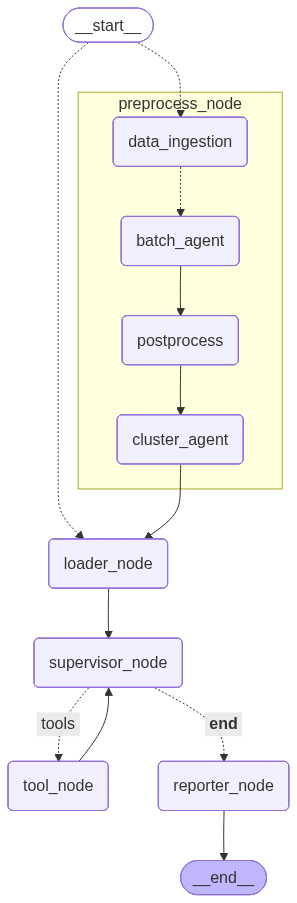

In [2]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle

png_bytes = main_graph.get_graph(xray=True).draw_mermaid_png(
    curve_style=CurveStyle.BASIS
)

display(Image(png_bytes))

In [3]:


from sqlalchemy import desc
from typing import List, Callable
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.chat_models import BaseChatModel
from langchain.messages import HumanMessage, AIMessage
from langchain_core.runnables import RunnableConfig
from pydantic import BaseModel , Field 
from langchain.tools import tool , ToolRuntime
import os
from Core.Workflows.SandBoxGraph import get_sandbox_graph
from Core.Workflows.PlotGraph import get_plotting_agent
from dotenv import load_dotenv
from Core.LLMS import build_llm_factory

load_dotenv()
llm_factory = build_llm_factory()
from pathlib import Path
import re
import pandas as pd
import base64

sandbox_graph_data = get_sandbox_graph(llm_factory["coder_llm_data_analysis"][0])
sandbox_graph_plot = get_sandbox_graph(llm_factory["coder_llm_plotting"][0])
plot_agent = get_plotting_agent(
    sandbox_graph=sandbox_graph_plot,
    prompt_llm=llm_factory["planner_llm"][0],
    image_llm=llm_factory["image_llm"][0],
)

In [4]:
for event in main_graph.stream(
    {
        "run_id": 12809,
        "messages": [
            HumanMessage(
                content="analyse product give the overall themes present and provide the theme with lowest average sentiment give tabular analysis"
            )
        ],
        "product_id": 0,
        "review_analysis": {},
        "plan": {},
        "current_sequence": -1,
    },
    config={
        "configurable": {
            "sandbox_graph": sandbox_graph_data,
            "plot_agent": plot_agent,
        }
    },
    stream_mode="updates",
):
    for node, value in event.items():
        print(f"\n🔹 Node executed: {node}")
        print("Update:", value)

        if "messages" in value and value["messages"]:
            value["messages"][-1].pretty_print()


🔹 Node executed: loader_node
Update: {'review_analysis': {'product_id': 0, 'review_list': ["IMPORTANT UPDATE (3/8/17): As you read my original review, please be aware that Amazon announced in early February (2017) a new firmware update that allows Amazon Tap owners to enable a hands-free option! By going into Settings in the Alexa app, you can now choose the hands-free option and have your Tap respond to voice commands without touching it, just like the Echo and Echo Dot! This is a fabulous development and something Tap owners have been hoping for. Thank you, Amazon!Since the lack of hands-free operation was the one major shortcoming of the Tap, this wonderful little device has now gotten a whole lot better. One thing to keep in mind, though, especially if you use your Tap on battery power: The hands-free mode will drain the battery more quickly, because it requires the microphone to be on at all times. But since you can easily toggle between hands-free or regular tap mode using the A

In [5]:
from IPython.display import display, Markdown

display(Markdown(value["messages"][-1].content))

# Analytical Insights from Product Review Data

This report provides an analysis of product review data, categorizing feedback into distinct themes and evaluating their associated sentiment.

## Overview of Themes and Sentiment

The reviews were analyzed and grouped into seven primary themes. For each theme, the number of keyphrases, unique reviews, and the average sentiment score were calculated. Sentiment scores range from 1 to 10, where higher values indicate more positive feedback.

| Theme                     | # Keyphrases | # Reviews (unique) | Avg. Sentiment |
|---------------------------|--------------|--------------------|----------------|
| Setup & Controls          | 38           | 36                 | **6.39**       |
| Voice & Alexa             | 49           | 48                 | 6.92           |
| Connectivity              | 23           | 23                 | 7.09           |
| Battery & Power           | 35           | 31                 | 7.23           |
| Compatibility & Ecosystem | 27           | 26                 | 7.74           |
| Audio Quality             | 82           | 76                 | 7.99           |
| Portability & Design      | 44           | 42                 | 8.39           |

## Key Findings

*   **Overall Themes Identified:** The analysis identified seven distinct themes within the product reviews: *Setup & Controls, Voice & Alexa, Connectivity, Battery & Power, Compatibility & Ecosystem, Audio Quality,* and *Portability & Design*.
*   **Sentiment Distribution:** The average sentiment scores across these themes vary significantly, ranging from a low of **6.39** to a high of **8.39**. This indicates a diverse range of user experiences and opinions.
*   **Lowest Sentiment Theme:** The theme of *Setup & Controls* registered the lowest average sentiment score at **6.39**. This suggests that users encounter the most challenges or express the most dissatisfaction regarding the initial setup process and control mechanisms compared to other aspects of the product. This area warrants further investigation for potential improvements.

In [ ]:
for event in main_graph.stream(
    input={
        "run_id": 12810,
        "messages": [
            HumanMessage(
                content="give heat map between sentiment and themes "
            )
        ],
        "product_id": 0,
        "review_analysis": {},
        "plan": {},
        "current_sequence": -1,
    },
    config={
        "configurable": {
            "sandbox_graph": sandbox_graph_data,
            "plot_agent": plot_agent,
        }
    },
    stream_mode="updates",
):
    for node, value in event.items():
        print(f"\n Node executed: {node}")
        print("Update:", value)

        if "messages" in value and value["messages"]:
            value["messages"][-1].pretty_print()


 Node executed: loader_node
Update: {'review_analysis': {'product_id': 0, 'review_list': ["IMPORTANT UPDATE (3/8/17): As you read my original review, please be aware that Amazon announced in early February (2017) a new firmware update that allows Amazon Tap owners to enable a hands-free option! By going into Settings in the Alexa app, you can now choose the hands-free option and have your Tap respond to voice commands without touching it, just like the Echo and Echo Dot! This is a fabulous development and something Tap owners have been hoping for. Thank you, Amazon!Since the lack of hands-free operation was the one major shortcoming of the Tap, this wonderful little device has now gotten a whole lot better. One thing to keep in mind, though, especially if you use your Tap on battery power: The hands-free mode will drain the battery more quickly, because it requires the microphone to be on at all times. But since you can easily toggle between hands-free or regular tap mode using the Al

# Theme Correlation Analysis

This report presents the findings from the theme correlation analysis, visualizing the relationships between different themes identified in product reviews.

---

## Theme Correlation Heat Map

The Theme Correlation Heat Map visually represents the strength and direction of relationships between various review themes.

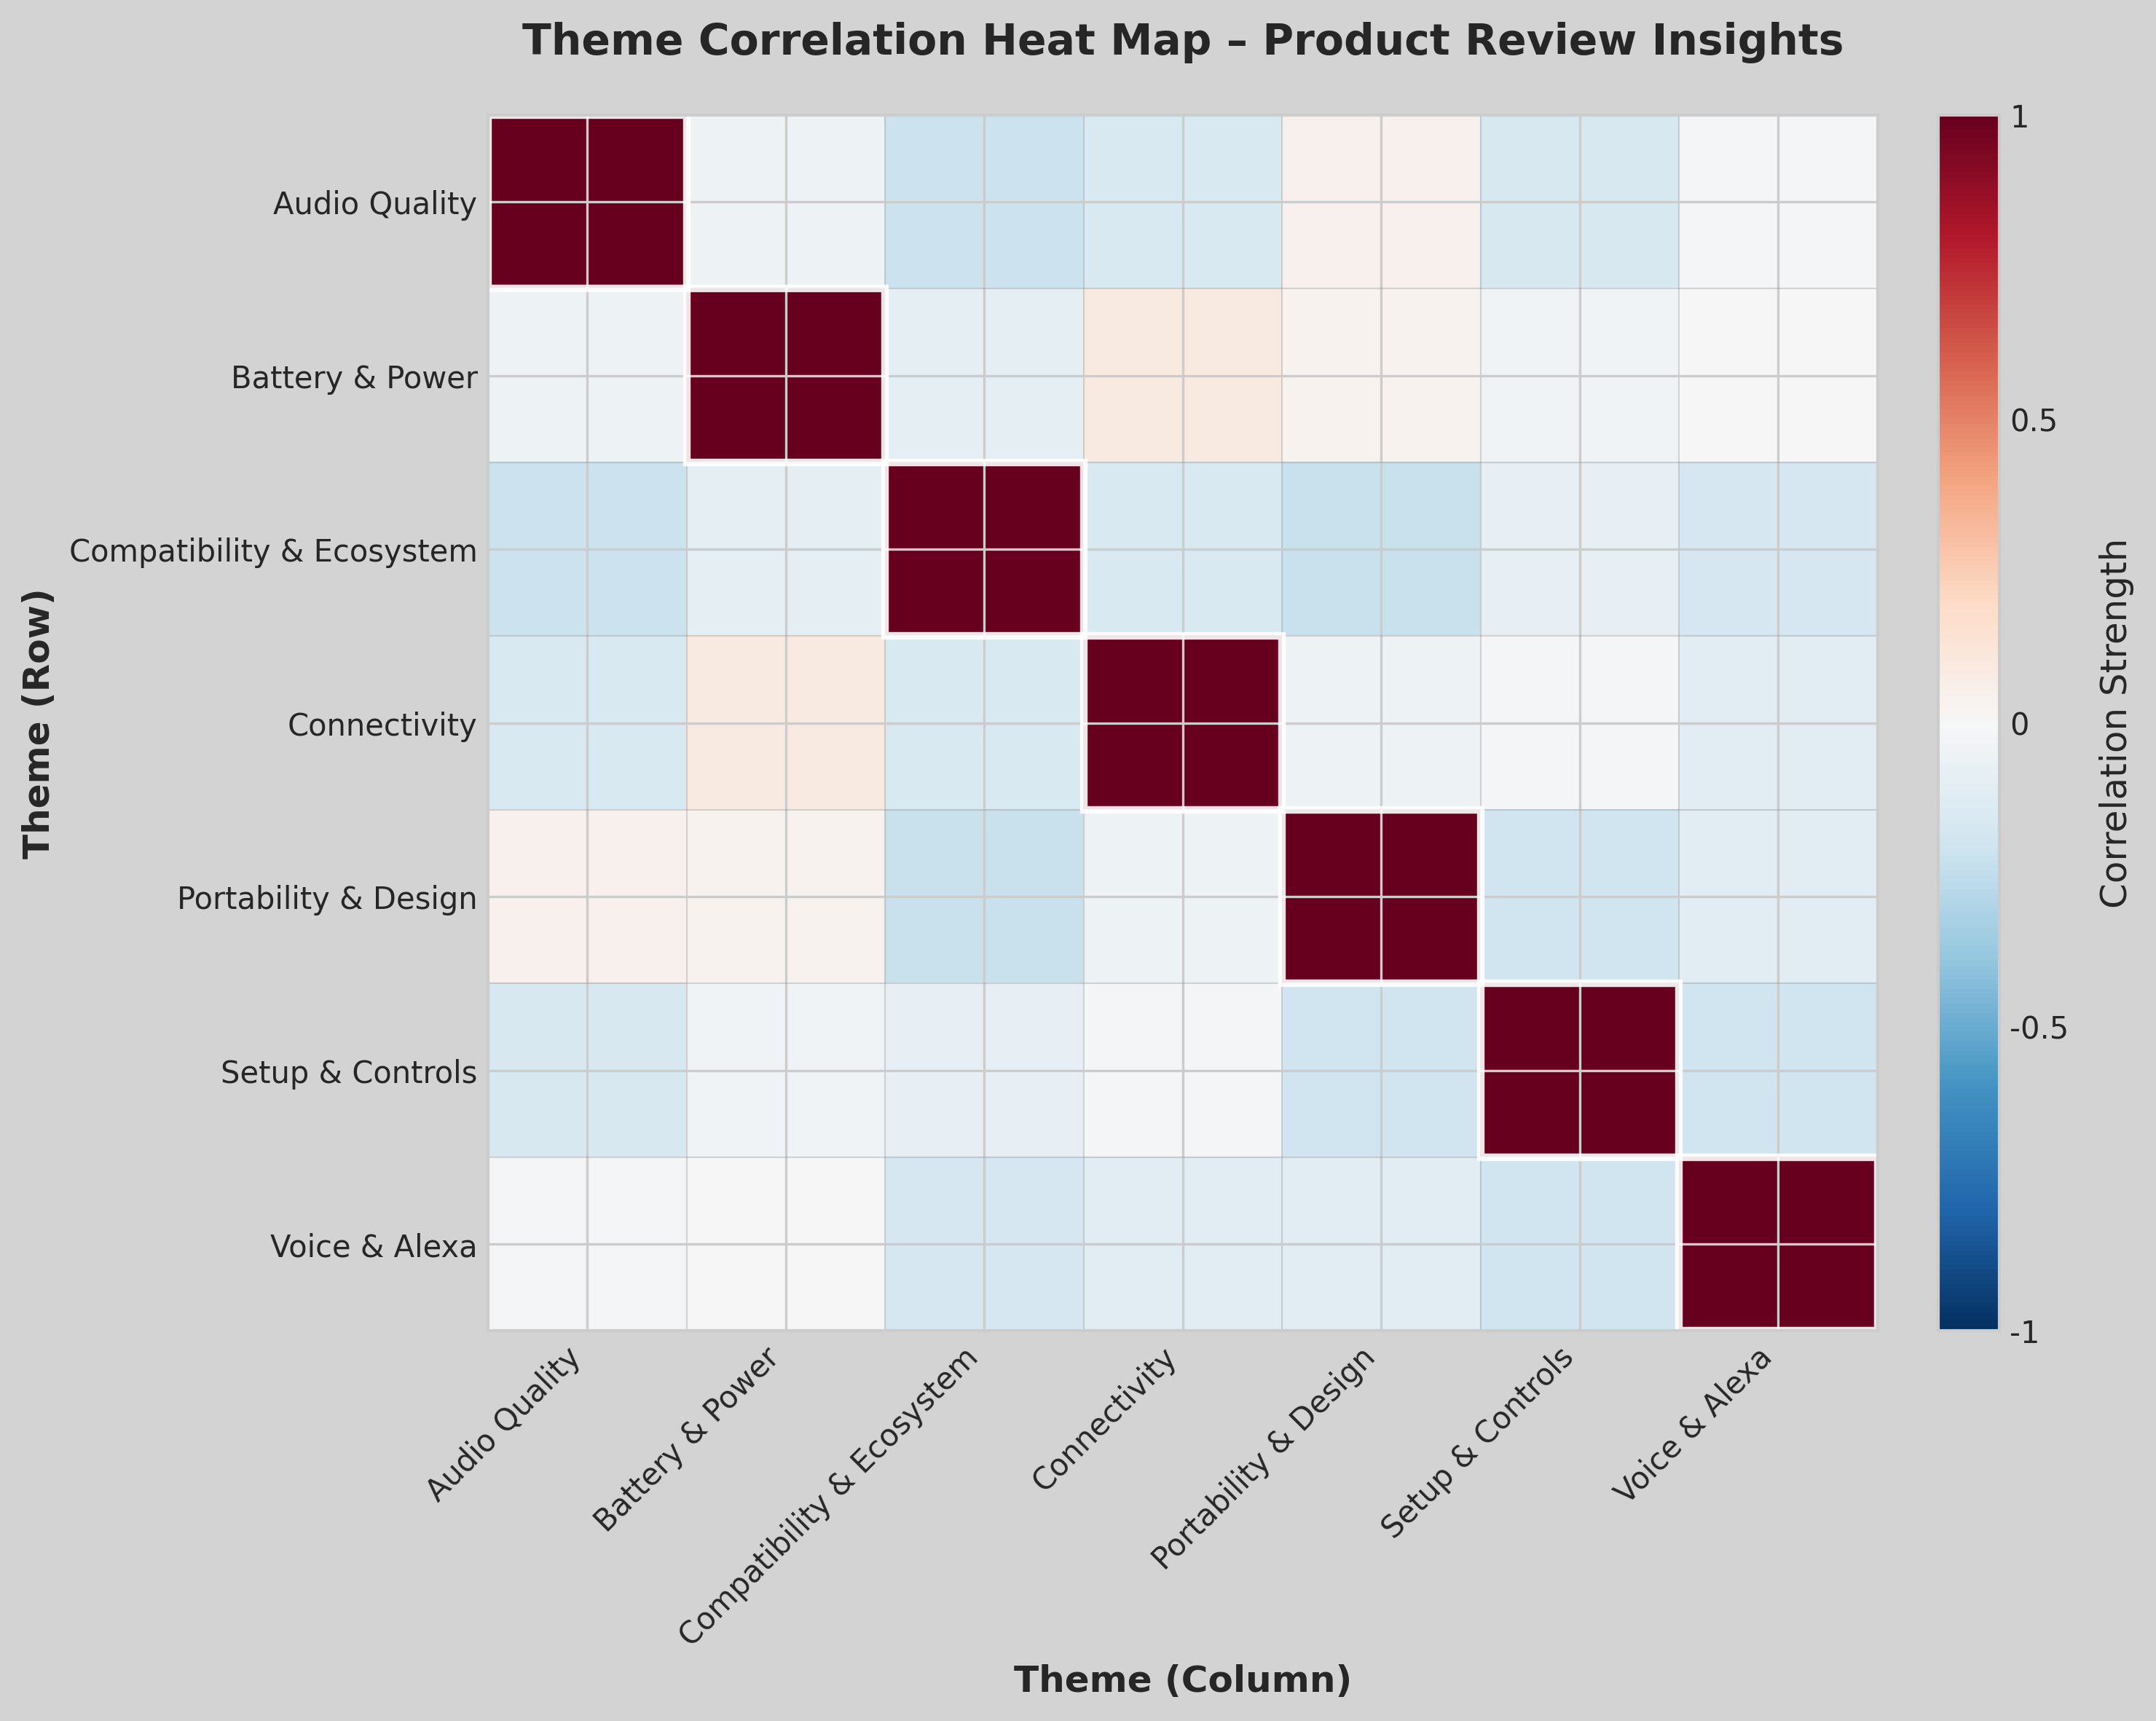

### Key Insights from the Heat Map:

*   **Weak Correlations:** The heat map predominantly displays light blue, white, and light red cells, visually confirming that all theme correlations are weak. This means that the absolute correlation coefficients are less than 0.6.
*   **Strongest Negative Correlations:**
    *   A correlation of -0.221 was observed between 'Compatibility & Ecosystem' and 'Portability & Design'.
    *   A correlation of -0.203 was observed between 'Setup & Controls' and 'Portability & Design'.
    These negative correlations suggest that these pairs of themes are rarely discussed together in reviews.
*   **Absence of Strong Positive Correlations:** No strong positive correlations are evident, indicating that review themes generally co-occur independently rather than clustering strongly.

---

## Overall Graphical Insight

The analysis of theme correlations in product reviews reveals that all relationships between themes are weak, with no strong positive or negative co-occurrence patterns. This suggests that customers tend to focus on specific aspects of a product in their reviews rather than providing feedback that spans multiple, strongly related themes.

In [11]:
from IPython.display import display, Markdown

display(Markdown(value["messages"][-1].content))